In [ ]:
import numpy as np
import math
from scipy.stats import chisquare
import matplotlib.pyplot as plt
from scipy.stats import t


### Part 1

In [ ]:
def get_g(i, A):
    #Target density function g(i) = A^i / i! (proportional to Poisson)
    return (A**i) / math.factorial(i)

def metropolis_hastings_poisson(A, m, n_samples=20000, burn_in=10000):
    #Generates samples from a truncated Poisson distribution using the Metropolis-Hastings algorithm.
    
    samples = []
    current = 0  # Initial state X0
    
    total_iterations = n_samples + burn_in
    
    for i in range(total_iterations):
        # Propose a candidate state Y = X + Delta
        perturbation = np.random.choice([-1, 1])
        proposal = current + perturbation
        
        # Check boundaries [0, m]
        if 0 <= proposal <= m:
            # Calculate acceptance probability alpha = min(1, g(y)/g(x))
            g_y = get_g(proposal, A)
            g_x = get_g(current, A)
            alpha = min(1, g_y / g_x)
            
            # Acceptance decision
            if np.random.rand() < alpha:
                current = proposal # Accept Y: X_{i+1} = Y
            # Else: Reject Y: X_{i+1} = X (remains at current state)
        
        # Discard burn-in period and store samples
        if i >= burn_in:
            samples.append(current)
            
    return np.array(samples)

# Parameters
A = 8.0  #mean_inter_arrival_time * mean_service_time  = 1*8
m = 10 

# Generate samples
samples = metropolis_hastings_poisson(A, m)

# Chi-square goodness-of-fit test
states = np.arange(m + 1)
theoretical_weights = np.array([get_g(i, A) for i in states])
theoretical_dist = theoretical_weights / np.sum(theoretical_weights)

observed_freq = np.array([np.sum(samples == i) for i in states])
expected_freq = theoretical_dist * len(samples)

chi2_stat, p_val = chisquare(f_obs=observed_freq, f_exp=expected_freq)

# Print results
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4f}")

Chi-square statistic: 70.7761
p-value: 0.0000


## Part 2

In [ ]:
A1, A2 = 4, 4

def P(i, j, c, A1, A2):
        
        if i < 0 or j<0 or (i+j) > 10:
            return 0
        
        return c * ((A1**i)/math.factorial(i)) * ((A2**j)/math.factorial(j))
    
    
# Theoretical distribution
def compute_c(A1, A2, m):
    total = sum(
        (P(i, j, 1, A1, A2))
        for i in range(m+1)
        for j in range(m+1)
        if i + j <= m
    )
    return 1 / total


c = compute_c(4, 4, 10)
theoretical = np.zeros((11, 11))

for i in range(11):
    for j in range(11):
        if i + j <= 10:
            theoretical[i, j] = c * (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))
            
            
def empirical(samples, m):
    empirical = np.zeros((m+1, m+1))
    for i, j in samples:
        empirical[int(i), int(j)] += 1
    empirical /= len(samples)
    
    return empirical

### Generate samples from the Metropolis-Hastings algorithm

In [ ]:
def metropolis_hastings(A1=4, A2=4, m=10, n_samples=100):
    
    #Helper functions
    i, j = (0, 0) # Initialize x0
    
    samples = np.zeros((n_samples, 2))
    moves = [(1,0), (-1,0), (0,1), (0,-1)]
    
    for s in range(n_samples):
        # propose new state
        
        direction = np.random.choice(4)
        i_tilde, j_tilde = i + moves[direction][0], j + moves[direction][1]
  
        
        # acceptance ratio (c cancels)
        alpha = min(1, P(i_tilde, j_tilde, 0.0050, A1, A2) / P(i, j, 0.0050, A1, A2))
        
        u = np.random.rand()
        
        # accept or reject
        if  u < alpha:
            i, j = i_tilde, j_tilde
        
        samples[s, :] = i, j
    
    return samples
    

### Generate samples from the coordinatewise metropolis hastings

In [ ]:
def coordinate_wise_metropolis_hastings(A1=4, A2=4, m=10, n_samples=100):
    
    #Helper functions
    i, j = (0, 0) # Initialize x0
    
    samples = np.zeros((n_samples, 2))
    moves = [+1, -1]
    
    for s in range(n_samples):
        # Always update i
        i_tilde = i + np.random.choice(moves)
        
        alpha_i = min(1, P(i_tilde, j, 0.0050, A1, A2) / P(i, j, 0.0050, A1, A2))
        u_i = np.random.rand()
        
        if u_i < alpha_i:
            i = i_tilde
        
        # Always update j
        j_tilde = j + np.random.choice(moves)
        
        alpha_j = min(1, P(i, j_tilde, 0.0050, A1, A2) / P(i, j, 0.0050, A1, A2))
        u_j = np.random.rand()
        
        if u_j < alpha_j:
            j = j_tilde
        
        
        samples[s, :] = i, j
    
    return samples

### Gibbs sampling

In [ ]:
def crude_method(p_i, n): # From exercise 2
    U = np.random.rand(n) 
    F_x = np.cumsum(p_i)
    
    F_x_index = U[:, np.newaxis] > F_x[np.newaxis, :]
    index = np.argmax(~F_x_index, axis=1) + 1
    
    return index

def gibbs_sampling(theoretical, A1=4, A2=4, m=10, n_samples=100):
    
    
    i, j = (0, 0) # Initialize x0
    
    samples = np.zeros((n_samples, 2))
    
    for s in range(n_samples):
        
        # Update left coordinate
        p_i = theoretical[:, j] / np.sum(theoretical[:, j]) # Normalize prob
        i = crude_method(p_i, 1)[0] - 1
        
        
        # Update right coordinate
        p_j = theoretical[i, :] / np.sum(theoretical[i, :]) # Normalize prob
        j = crude_method(p_j, 1)[0] - 1
        
        samples[s, :] = i, j
        
    
    
    return samples

MH - Chi-square: 165.2343, p-value: 0.0000
CMH - Chi-square: 69.9937, p-value: 0.3137
Gibbs - Chi-square: 65.4792, p-value: 0.4600


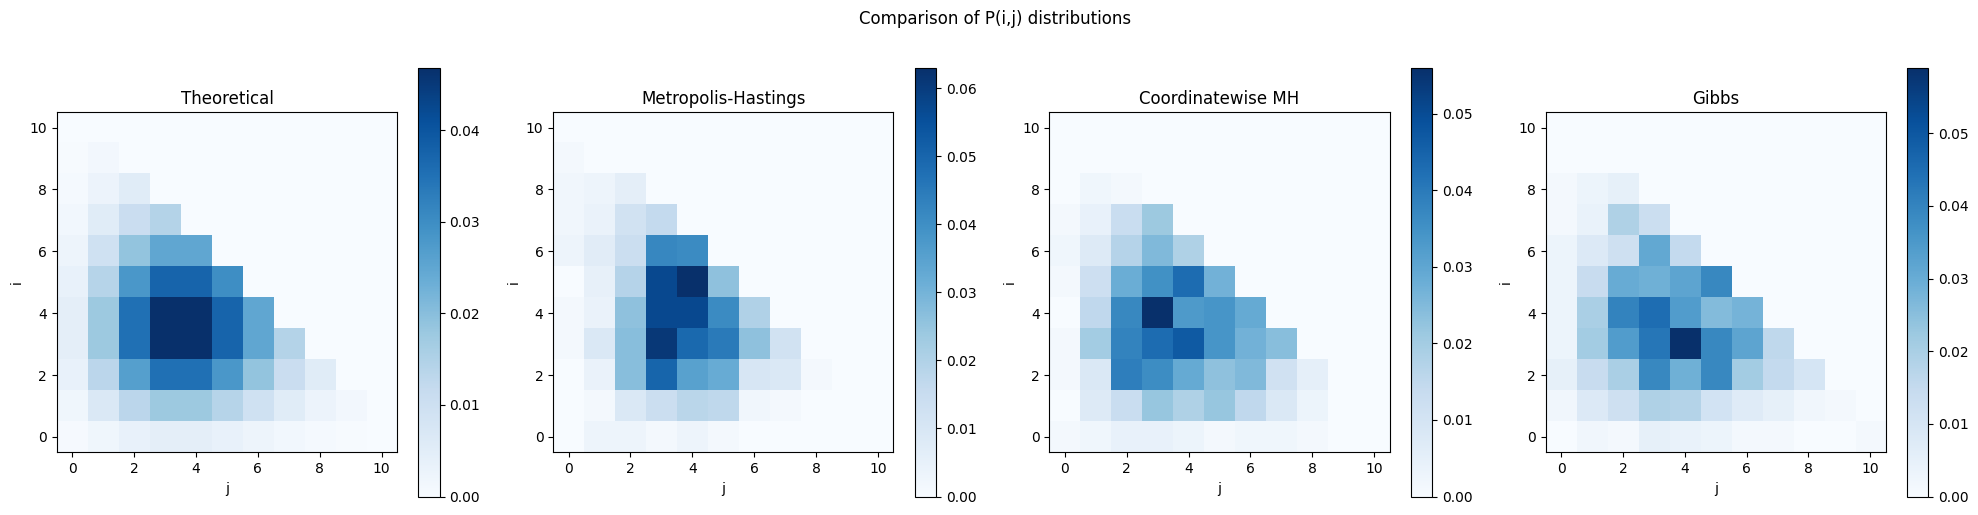

In [ ]:
A1, A2, m, n_samples = 4, 4, 10, 1000

samples_metropolis_hastings = metropolis_hastings(A1=A1, A2=A2, m=m, n_samples=n_samples)

empirical_mh = empirical(samples_metropolis_hastings, m)


samples_coordinate_metropolis_hastings = coordinate_wise_metropolis_hastings(A1=A1, A2=A2, m=m, n_samples=n_samples)

empirical_cmh = empirical(samples_coordinate_metropolis_hastings, m)


samples_gibbs = gibbs_sampling(theoretical, A1=A1, A2=A2, m=m, n_samples=n_samples)

empirical_gibbs = empirical(samples_gibbs, m)



mask = theoretical.flatten() > 0

# Metropolis-Hastings
T, p_value = chisquare(empirical_mh.flatten()[mask] * n_samples, 
                        f_exp=theoretical.flatten()[mask] * n_samples)
print(f"MH - Chi-square: {T:.4f}, p-value: {p_value:.4f}")

# Coordinatewise MH
T, p_value = chisquare(empirical_cmh.flatten()[mask] * n_samples, 
                        f_exp=theoretical.flatten()[mask] * n_samples)
print(f"CMH - Chi-square: {T:.4f}, p-value: {p_value:.4f}")

# Gibbs
T, p_value = chisquare(empirical_gibbs.flatten()[mask] * n_samples, 
                        f_exp=theoretical.flatten()[mask] * n_samples)
print(f"Gibbs - Chi-square: {T:.4f}, p-value: {p_value:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

distributions = [theoretical, empirical_mh, empirical_cmh, empirical_gibbs]
titles = ['Theoretical', 'Metropolis-Hastings', 'Coordinatewise MH', 'Gibbs']

for ax, dist, title in zip(axes, distributions, titles):
    im = ax.imshow(dist, origin='lower', cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('j')
    ax.set_ylabel('i')
    plt.colorbar(im, ax=ax)

plt.suptitle('Comparison of P(i,j) distributions', y=1.02)
plt.tight_layout()
plt.show()



Part 3.a - Prior Sample

In [ ]:
rho = 0.5

Sigma = np.array([
    [1, rho],
    [rho, 1]
])

xi, gamma = np.random.multivariate_normal(
    mean=[0, 0],
    cov=Sigma
)

theta = np.exp(xi)
psi = np.exp(gamma)

print("theta =", theta)
print("psi =", psi)

theta = 1.5126255818300547
psi = 3.1284420851934995


Part 3.b - Simulate Data

In [ ]:
n = 10

x = np.random.normal(
    loc=theta,
    scale=np.sqrt(psi),
    size=n
)

In [ ]:
xbar = np.mean(x)

s2 = np.var(
    x,
    ddof=1
)

print("mean =",xbar)
print("variance =",s2)

mean = 0.9711852138617868
variance = 5.819577602443456


Part 3.c - Derive Posterior

In [ ]:
rho = 0.5

def log_posterior(theta, psi, data):

    if theta <= 0:
        return -np.inf

    if psi <= 0:
        return -np.inf

    n = len(data)

    sse = np.sum(
        (data-theta)**2
    )

    loglik = (
        -n/2*np.log(psi)
        -sse/(2*psi)
    )

    logprior = (
        -np.log(theta)
        -np.log(psi)
        -
        (
            np.log(theta)**2
            -
            2*rho*np.log(theta)*np.log(psi)
            +
            np.log(psi)**2
        )
        /
        (
            2*(1-rho**2)
        )
    )

    return loglik + logprior

Part 3.(d,e) - Metropolis-Hastings

In [ ]:
def likelihood(mean, var, X):
    if var <= 0:
        return -np.inf
    return np.sum(-0.5 * np.log(2 * np.pi * var) - (X - mean)**2 / (2 * var))

def prior(mean, var):
    if mean <= 0 or var <= 0:
        return -np.inf
    lm, lv = np.log(mean), np.log(var)
    return -(lm**2 - 2*rho*lm*lv + lv**2) / (2*(1-rho**2)) - lm - lv

def posterior(mean, var, X):
    return likelihood(mean, var, X) + prior(mean, var)

In [ ]:
rho = 0.5
n = 10

log_mean = np.random.normal(0, 1)
log_variance = np.random.normal(rho * log_mean, np.sqrt(1 - rho**2))

mean = np.exp(log_mean)
variance = np.exp(log_variance)

X = np.random.normal(loc=mean, scale=np.sqrt(variance), size=n)
print(f"Observations: {X}")

Observations: [ 0.12752871  0.53339103  0.47156292 -0.12471738  0.26649298  1.10859913
 -0.32981521  1.43604917  1.29130818  0.05043476]


In [99]:
def run_mh(X, mean_init, var_init, n_samples=100000, burn_in=10000, step=0.1):
    samples_mean, samples_var = [], []
    m, v = mean_init, var_init
    for k in range(n_samples + burn_in):
        m_new = m + np.random.normal(0, step)
        v_new = v + np.random.normal(0, step)
        r = np.exp(posterior(m_new, v_new, X) - posterior(m, v, X))
        if np.random.uniform() < min(1, r):
            m, v = m_new, v_new
        if k >= burn_in:
            samples_mean.append(m)
            samples_var.append(v)
    return np.mean(samples_mean), np.mean(samples_var)

est_mean, est_var = run_mh(X, mean, variance)

In [101]:
for n in [100, 1000]:
    X_n = np.random.normal(loc=mean, scale=np.sqrt(variance), size=n)
    est_mean, est_var = run_mh(X_n, mean, variance)
    print("N =", n, "Mean:",est_mean,"Variance:",est_var)

print("Mean:", mean, "Variance:", variance)

N = 100 Mean: 0.31567854366062353 Variance: 0.31608633535390834
N = 1000 Mean: 0.2936723998592162 Variance: 0.2773637040159995
Mean: 0.30572271706299764 Variance: 0.2687539237483324
